In [ ]:
可快速生成符合规范的训练过程图，用于直观判断模型收敛速度、是否出现过拟合等核心训练特征。

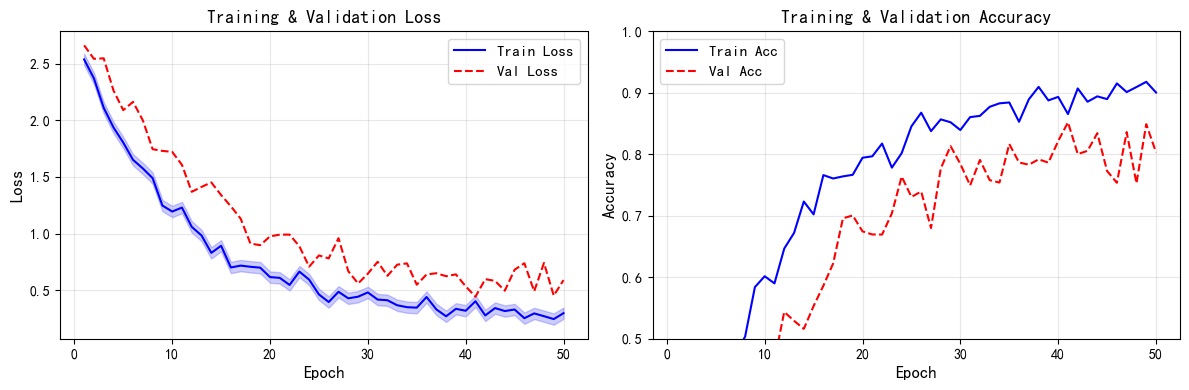

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

%matplotlib inline
# 设置字体（中文环境）
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

epochs = np.arange(1, 51)
train_loss = 2.5 * np.exp(-0.1 * epochs) + 0.3 + 0.05 * np.random.randn(50)
val_loss   = 2.5 * np.exp(-0.08 * epochs) + 0.5 + 0.08 * np.random.randn(50)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左图：Loss 曲线
axes[0].plot(epochs, train_loss, 'b-', linewidth=1.5, label='Train Loss')
axes[0].plot(epochs, val_loss,   'r--', linewidth=1.5, label='Val Loss')
axes[0].fill_between(epochs, train_loss-0.05, train_loss+0.05, alpha=0.2, color='blue')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training & Validation Loss', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 右图：Accuracy 曲线
train_acc = 1 - train_loss / 3
val_acc   = 1 - val_loss / 3
axes[1].plot(epochs, train_acc, 'b-', label='Train Acc')
axes[1].plot(epochs, val_acc,   'r--', label='Val Acc')
axes[1].set_ylim(0.5, 1.0)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training & Validation Accuracy', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curve.pdf', dpi=300, bbox_inches='tight')  # 保存为PDF（论文质量）
plt.show()

In [ ]:
多分类模型结果分析，直观查看各类别错分情况，定位哪两类容易互相混淆，针对性优化特征、模型。

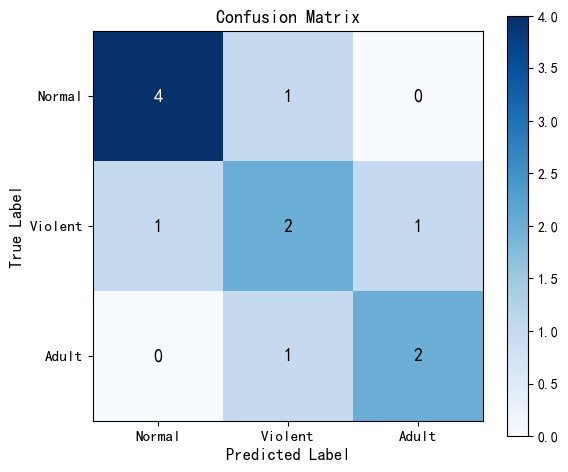

In [36]:
from sklearn.metrics import confusion_matrix

y_true = [0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 0]
y_pred = [0, 2, 2, 0, 0, 2, 0, 1, 1, 0, 1, 1]
cm = confusion_matrix(y_true, y_pred)
labels = ['Normal', 'Violent', 'Adult']

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im)
ax.set_xticks(range(len(labels))), ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=11)
ax.set_yticklabels(labels, fontsize=11)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=13)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
该代码是机器学习多方法指标对比通用模板：

1. 只需替换`methods`、`auc_scores`两组列表即可适配任意多模型指标对比；
2. 配色、标注、网格、保存逻辑全套标准化，可作为实验可视化固定范式；
3. 适合分类、NLP、CV 各类算法横向效果对比。

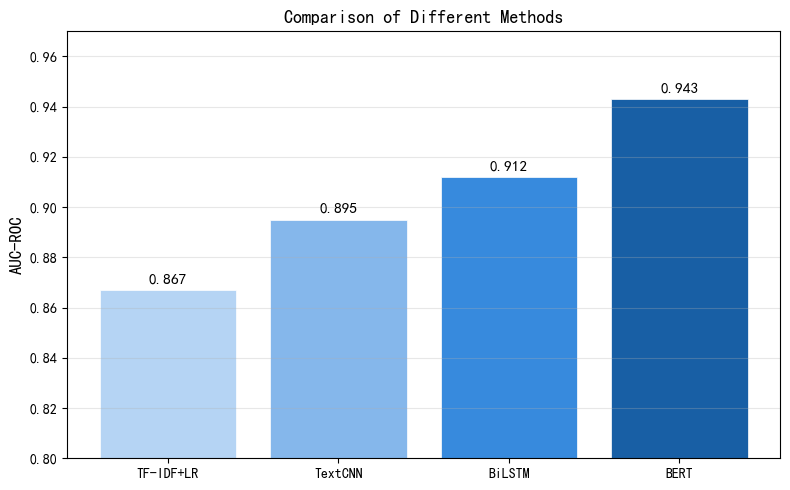

In [37]:
methods = ['TF-IDF+LR', 'TextCNN', 'BiLSTM', 'BERT']
auc_scores = [0.867, 0.895, 0.912, 0.943]
colors = ['#B5D4F4', '#85B7EB', '#378ADD', '#185FA5']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(methods, auc_scores, color=colors, edgecolor='white', linewidth=0.5)
ax.set_ylim(0.80, 0.97)
ax.set_ylabel('AUC-ROC', fontsize=12)
ax.set_title('Comparison of Different Methods', fontsize=13)
ax.grid(axis='y', alpha=0.3)
for bar, score in zip(bars, auc_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{score:.3f}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('method_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
1. 是风控、情感二分类、异常检测等任务最常用的可视化方案；
2. 搭配 AUC 数值，既有可视化趋势，又有精确量化指标，完整支撑模型优劣论证。

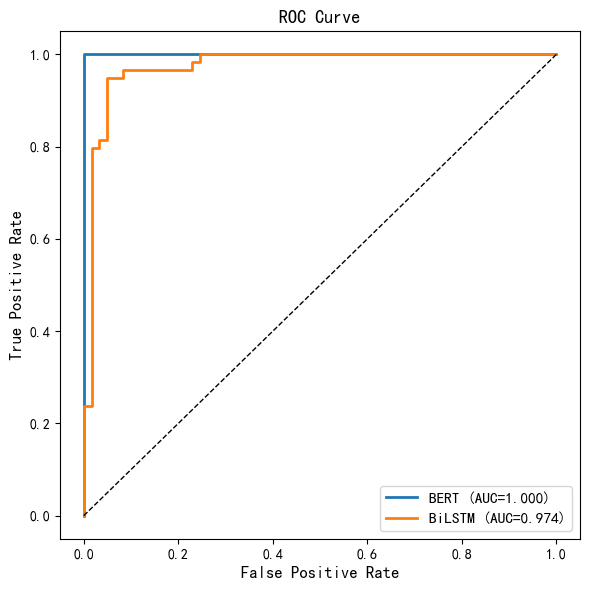

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc as calc_auc


np.random.seed(123)  # 固定随机种子，结果可复现
num_samples = 120   
y_true = np.random.randint(0, 2, size=num_samples)  # 二分类真实标签

bert_scores = np.clip(0.15 + y_true * 0.7 + np.random.normal(0, 0.12, num_samples), 0, 1)
lstm_scores = np.clip(0.3 + y_true * 0.45 + np.random.normal(0, 0.18, num_samples), 0, 1)

fig, ax = plt.subplots(figsize=(6, 6))
for name, y_score in [('BERT', bert_scores), ('BiLSTM', lstm_scores)]:
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = calc_auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('roc_curve.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
用于验证模型特征：簇分得越开，代表特征区分效果越好。
适合文本、图像各类深度学习任务的特征分布验证。

In [ ]:
from sklearn.manifold import TSNE

features = np.random.randn(500, 128)   # 500个128维特征
labels_arr = np.random.randint(0, 3, 500)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = tsne.fit_transform(features)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels_arr,
                     cmap='tab10', alpha=0.7, s=20)
plt.colorbar(scatter)
ax.set_title('Feature Space Visualization (t-SNE)', fontsize=13)
plt.tight_layout()
plt.savefig('tsne.pdf', dpi=300, bbox_inches='tight')
plt.show()